In [1]:
import pandas as pd

# Load first file
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master/IRAhandle_tweets_1.csv")

# Append files 2–12
for i in range(2, 13):
    url = f"https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master/IRAhandle_tweets_{i}.csv"
    df_temp = pd.read_csv(url)
    df = pd.concat([df, df_temp], ignore_index=True)

df.head()

/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_45321/1280567122.py:9: DtypeWarning: Columns (0,15,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(url)
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_45321/1280567122.py:9: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(url)
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_45321/1280567122.py:9: DtypeWarning: Columns (10,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(url)


,external_author_id,author,content,region,language,publish_date,harvested_date,following,followers,updates,...,account_type,retweet,account_category,new_june_2018,alt_external_id,tweet_id,article_url,tco1_step1,tco2_step1,tco3_step1
0,906000000000000000,10_GOP,"""We have a sitting Democrat US Senator on tria...",Unknown,English,10/1/2017 19:58,10/1/2017 19:59,1052,9636,253,...,Right,0,RightTroll,0,905874659358453760,914580356430536707,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914580356430...,NaN,NaN
1,906000000000000000,10_GOP,Marshawn Lynch arrives to game in anti-Trump s...,Unknown,English,10/1/2017 22:43,10/1/2017 22:43,1054,9637,254,...,Right,0,RightTroll,0,905874659358453760,914621840496189440,http://twitter.com/905874659358453760/statuses...,https://twitter.com/damienwoody/status/9145685...,NaN,NaN
2,906000000000000000,10_GOP,Daughter of fallen Navy Sailor delivers powerf...,Unknown,English,10/1/2017 22:50,10/1/2017 22:51,1054,9637,255,...,Right,1,RightTroll,0,905874659358453760,914623490375979008,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/913231923715...,NaN,NaN
3,906000000000000000,10_GOP,JUST IN: President Trump dedicates Presidents ...,Unknown,English,10/1/2017 23:52,10/1/2017 23:52,1062,9642,256,...,Right,0,RightTroll,0,905874659358453760,914639143690555392,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914639143690...,NaN,NaN
4,906000000000000000,10_GOP,"19,000 RESPECTING our National Anthem! #StandF...",Unknown,English,10/1/2017 2:13,10/1/2017 2:13,1050,9645,246,...,Right,1,RightTroll,0,905874659358453760,914312219952861184,http://twitter.com/905874659358453760/statuses...,https://twitter.com/realDonaldTrump/status/914...,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
 15  alt_external_id     object
 16  tweet_id            int64 
 17  article_url         object
 18  tco1_step1          object
 19  tco2_step1          object
 20  tco3_step1          object
dtypes: int64(6), object(15)
memory usage: 468.7+ MB


In [3]:
cleaned_df = df.drop(columns=["tweet_id", "alt_external_id", "article_url", "tco1_step1", "tco2_step1", "tco3_step1"])

In [4]:
cleaned_df["post_type"].head()

0        NaN
1        NaN
2    RETWEET
3        NaN
4    RETWEET
Name: post_type, dtype: object

In [5]:
cleaned_df["post_type"].groupby(cleaned_df["post_type"]).count()

post_type
QUOTE_TWEET      39938
RETWEET        1239753
Name: post_type, dtype: int64

In [6]:
cleaned_df["region"].groupby(cleaned_df["region"]).count()

region
Afghanistan                     3318
Austria                            1
Azerbaijan                     94916
Belarus                        27335
Canada                           608
Czech Republic                     7
Denmark                            1
Egypt                            232
Estonia                            1
Finland                           20
France                           942
Germany                        27178
Greece                            81
Hong Kong                          3
India                             22
Iran, Islamic Republic of        541
Iraq                           11117
Israel                          3604
Italy                          13474
Japan                            108
Latvia                             7
Malaysia                        4932
Mexico                            41
Russian Federation             37052
Samoa                             32
Saudi Arabia                      55
Serbia                         

In [7]:
cleaned_df.replace({"post_type": {None: "TWEET"}}, inplace=True)

In [8]:
cleaned_df["post_type"].head()

0      TWEET
1      TWEET
2    RETWEET
3      TWEET
4    RETWEET
Name: post_type, dtype: object

In [9]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [10]:
cleaned_df["external_author_id"] = cleaned_df["external_author_id"].astype(str) 
cleaned_df["author"] = cleaned_df["author"].astype(str) 
cleaned_df["content"] = cleaned_df["content"].astype(str) 
cleaned_df["region"] = cleaned_df["region"].astype(str)
cleaned_df["language"] = cleaned_df["language"].astype(str)
cleaned_df["account_category"] = cleaned_df["account_category"].astype(str)

In [11]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [12]:
cleaned_df["publish_date"] = pd.to_datetime(cleaned_df["publish_date"], format="mixed", errors="coerce")
min_date = cleaned_df["publish_date"].min()
max_date = cleaned_df["publish_date"].max()
cleaned_df["publish_date"] = -1 + 2 * (cleaned_df["publish_date"] - min_date) / (max_date - min_date)
cleaned_df["publish_date"].describe()

count    2.925313e+06
mean     4.230922e-01
std      2.306454e-01
min     -1.000000e+00
25%      2.160120e-01
50%      4.615388e-01
75%      6.104632e-01
max      1.000000e+00
Name: publish_date, dtype: float64

In [13]:
import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sia.polarity_scores("TRUMP 2020!!! Make America Great Again!")

{'neg': 0.0, 'neu': 0.487, 'pos': 0.513, 'compound': 0.7405}

In [14]:
import re

english_df = cleaned_df[cleaned_df["language"] == "English"].copy()

_rt_prefix = re.compile(r"^RT @\w+:\s*")
_url = re.compile(r"https?://\S+|www\.\S+")

def clean_tweet(text: str) -> str:
    text = _rt_prefix.sub("", text)
    text = _url.sub("", text)
    return text.strip()

english_df["content_clean"] = english_df["content"].map(clean_tweet)
print(f"English tweets: {len(english_df):,}")
english_df[["content", "content_clean"]].head()

English tweets: 2,105,264


,content,content_clean
0,"""We have a sitting Democrat US Senator on tria...","""We have a sitting Democrat US Senator on tria..."
1,Marshawn Lynch arrives to game in anti-Trump s...,Marshawn Lynch arrives to game in anti-Trump s...
2,Daughter of fallen Navy Sailor delivers powerf...,Daughter of fallen Navy Sailor delivers powerf...
3,JUST IN: President Trump dedicates Presidents ...,JUST IN: President Trump dedicates Presidents ...
4,"19,000 RESPECTING our National Anthem! #StandF...","19,000 RESPECTING our National Anthem! #StandF..."


In [15]:
from tqdm.auto import tqdm
tqdm.pandas(desc="VADER")

scores = english_df["content_clean"].progress_map(sia.polarity_scores)
scores_df = pd.DataFrame(scores.tolist(), index=english_df.index)
scores_df.columns = ["sent_neg", "sent_neu", "sent_pos", "sent_compound"]

english_df = pd.concat([english_df, scores_df], axis=1)
english_df[["content_clean", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head()

VADER:   0%|          | 0/2105264 [00:00<?, ?it/s]

,content_clean,sent_neg,sent_neu,sent_pos,sent_compound
0,"""We have a sitting Democrat US Senator on tria...",0.000,1.000,0.000,0.0000
1,Marshawn Lynch arrives to game in anti-Trump s...,0.000,1.000,0.000,0.0000
2,Daughter of fallen Navy Sailor delivers powerf...,0.208,0.660,0.132,-0.1531
3,JUST IN: President Trump dedicates Presidents ...,0.000,1.000,0.000,0.0000
4,"19,000 RESPECTING our National Anthem! #StandF...",0.000,0.542,0.458,0.6399


In [16]:
english_df["sent_compound"].describe()

count    2.105264e+06
mean    -3.906493e-02
std      4.184965e-01
min     -9.945000e-01
25%     -3.400000e-01
50%      0.000000e+00
75%      2.023000e-01
max      9.991000e-01
Name: sent_compound, dtype: float64

In [17]:
english_df.groupby("account_category")["sent_compound"].agg(["mean", "std", "count"]).sort_values("mean")

,mean,std,count
account_category,,,
NewsFeed,-0.117536,0.391601,596593
RightTroll,-0.051537,0.445338,699368
Fearmonger,-0.022814,0.431056,10855
LeftTroll,0.024806,0.438192,416680
HashtagGamer,0.028036,0.366757,236092
NonEnglish,0.032465,0.409098,26163
Commercial,0.051879,0.318314,112580
Unknown,0.075726,0.425028,6933


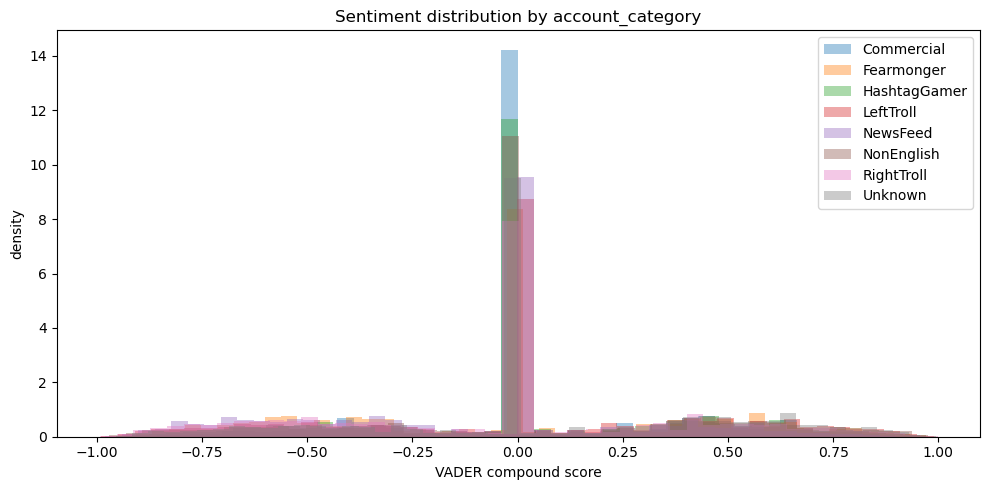

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in english_df.groupby("account_category"):
    grp["sent_compound"].plot(kind="hist", bins=50, alpha=0.4, label=cat, ax=ax, density=True)
ax.set_xlabel("VADER compound score")
ax.set_ylabel("density")
ax.set_title("Sentiment distribution by account_category")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
for cat in english_df["account_category"].unique():
    sub = english_df[english_df["account_category"] == cat]
    print(f"\n=== {cat} ===")
    print("most positive:", sub.loc[sub["sent_compound"].idxmax(), "content_clean"][:140])
    print("most negative:", sub.loc[sub["sent_compound"].idxmin(), "content_clean"][:140])


=== RightTroll ===
most positive: We win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we w
most negative: 1. Kill the bastard 2. Kill the bastard 3. Kill the bastard 4. Kill the bastard 5. Kill the bastard 6. ...

=== Fearmonger ===
most positive: Generosity, freedom, and love will create the most beautiful relationship: an ongoing romance.
most negative: i hate that im sensitive and jealous and stupid and quiet and ugly and annoying

=== NonEnglish ===
most positive: '@marienassar_ Good morning dearest Marie, have a wonderful day my best friend, hugs and kisses �☀����
most negative: '@ThoStranger those kids are being killed by these terrorist groups they are dangerous and criminal sent bu #usa and #saudiarabia to kill'

=== LeftTroll ===
most positive: '@ngremmy NEWARK MUST BE SAVED: URGENT GORGEOUS 2 YR C/W Sis JOLLY (&amp; 9 KITTIES: SAFE) FRIENDLY AFRAID BFF KITTY WITH LOVE ANYONE WOULD 
most negat

In [20]:
features_df = english_df[[
    "author",
    "publish_date",
    "following",
    "followers",
    "updates",
    "post_type",
    "account_type",
    "retweet",
    "new_june_2018",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound",
    "account_category",
]].copy()

features_df.head()

,author,publish_date,following,followers,updates,post_type,account_type,retweet,new_june_2018,sent_neg,sent_neu,sent_pos,sent_compound,account_category
0,10_GOP,0.791291,1052,9636,253,TWEET,Right,0,0,0.000,1.000,0.000,0.0000,RightTroll
1,10_GOP,0.791390,1054,9637,254,TWEET,Right,0,0,0.000,1.000,0.000,0.0000,RightTroll
2,10_GOP,0.791394,1054,9637,255,RETWEET,Right,1,0,0.208,0.660,0.132,-0.1531,RightTroll
3,10_GOP,0.791431,1062,9642,256,TWEET,Right,0,0,0.000,1.000,0.000,0.0000,RightTroll
4,10_GOP,0.790650,1050,9645,246,RETWEET,Right,1,0,0.000,0.542,0.458,0.6399,RightTroll


In [21]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2105264 entries, 0 to 2925126
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   author            object 
 1   publish_date      float64
 2   following         int64  
 3   followers         int64  
 4   updates           int64  
 5   post_type         object 
 6   account_type      object 
 7   retweet           int64  
 8   new_june_2018     int64  
 9   sent_neg          float64
 10  sent_neu          float64
 11  sent_pos          float64
 12  sent_compound     float64
 13  account_category  object 
dtypes: float64(5), int64(5), object(4)
memory usage: 240.9+ MB
